**<h1> Manipulating Images </h1>**


Estimated time needed: **60** minutes


<h2>Objectives</h2>


In this lab, you will learn how to manipulate images, both as arrays and PIL image objects. You will learn how to copy an image to avoid aliasing. We will cover flipping images and cropping images. You will also learn to change pixel images; this will allow you to draw shapes, write text and superimpose images over other images.


<ul>
    <li><a href='#MI'>Manipulating Images </a>
        <ul>
            <li>Copying Images  </li>
            <li>Fliping Images </li>
            <li>Cropping an Image </li>
            <li>Changing Specific Image Pixels </li>
     
  
    
</ul>


----


Download the images for the lab:


In [62]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cat.png -O cat.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png -O lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png -O baboon.png

zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget


We will be using these imported functions in the lab:


In [ ]:
# import các thư viện cần thiết
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

## Copying Images


If you want to reassign an array to another variable, you should use the `copy` method. 


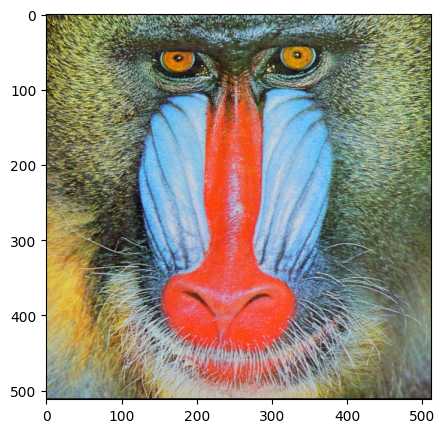

In [ ]:
# Mở ảnh baboon.png, chuyển thành mảng numpy và hiển thị ảnh
baboon = np.array(Image.open('baboon.png'))
plt.figure(figsize=(5,5))
plt.imshow(baboon )
plt.show()

If we do not apply the method `copy()`, the two variables would point to the same location in memory:


In [ ]:
# gán biến A bằng baboon
A = baboon

We use the  `id`  function to find a variable's memory address; we see the objects in the memory space which the variables `A` and `baboon` point to are the same.


In [ ]:
# kiểm tra id của A và baboon
id(A) == id(baboon)

True

However, if we apply method `copy()`, their memory addresses are different.


In [ ]:
# sao chép baboon thành B và kiểm tra id
B = baboon.copy()
id(B)==id(baboon)

False

There may be unexpected behaviours when two variables point to the same object in memory. Consider the array `baboon`. If we set all its entries to zero, all entires in `A` will become zero as well. However, as `baboon` and `B` points to different objects, the values in `B` will not be affected. 


In [ ]:
# đặt tất cả pixel của mảng baboon thành 0
baboon[:,:,] = 0

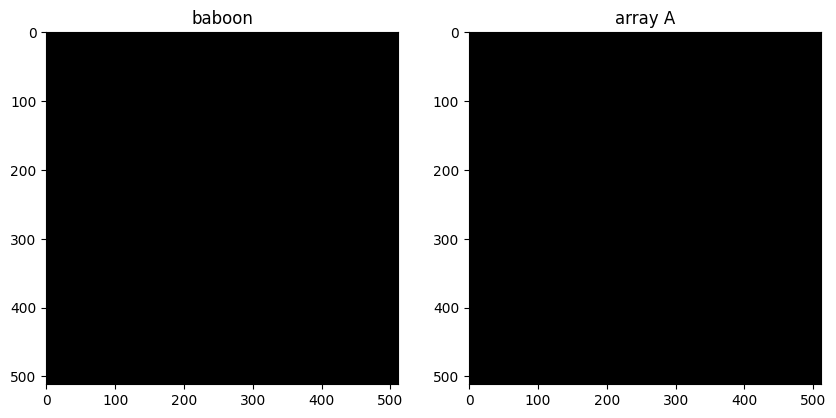

In [ ]:
# hiển thị baboon và A để kiểm tra sự thay đổi
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(baboon)
plt.title("baboon")
plt.subplot(122)
plt.imshow(A)
plt.title("array A")
plt.show()

We see they are the same. This behaviour is called aliasing. Aliasing happens whenever one variable's value is assigned to another variable. Variables are references to values on the memory. 

We can also compare <code>baboon</code> and array <code>B</code>:


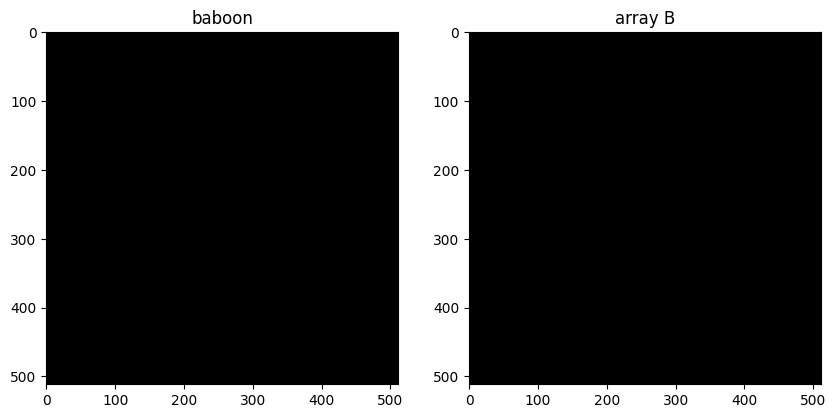

In [ ]:
# hiển thị baboon và B để kiểm tra (vẫn giống A do sao chép)
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(baboon)
plt.title("baboon")
plt.subplot(122)
plt.imshow(B)
plt.title("array B")
plt.show()


If a PIL function does not return a new image, the same principle applies. We will go over some examples later on. 


## Flipping Images 


Flipping images involves reordering the indices of the pixels such that it changes the orientation of the image. Consider the following image:


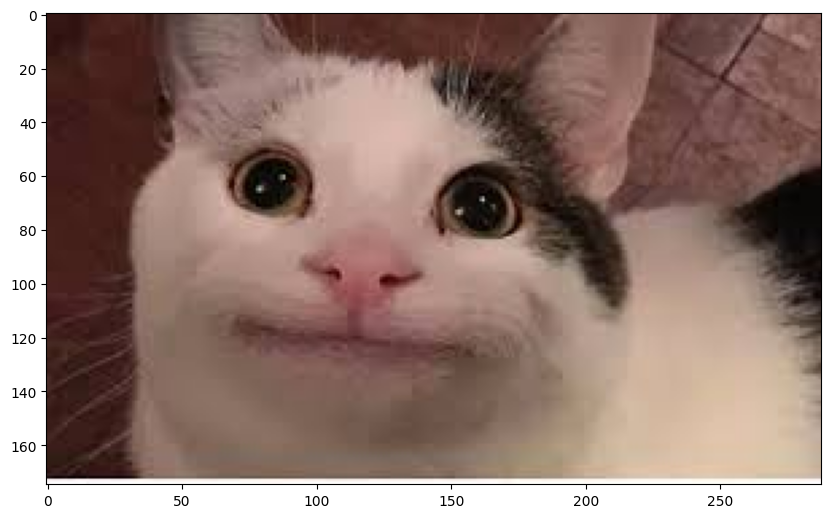

In [72]:
# mở ảnh cat.png và hiển thị
image = Image.open("cat.png")
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.show()

We can cast it to an array and find its shape:


In [73]:
# chuyển PIL image thành numpy array và in kích thước (width, height, channels)
array = np.array(image)
width, height, C = array.shape
print('width, height, C', width, height, C)


width, height, C 175 288 3


Let's flip, i.e rotate vertically, the image. Let's try the traditional approach. First, we create an array of the same size with datatype <code>np.uint8</code>.


In [74]:
# tạo mảng numpy trống với kích thước giống array gốc, kiểu uint8
array_flip = np.zeros((width, height, C), dtype=np.uint8)

We assign the first row of pixels of the original array to the new array’s last row. We repeat the process for every row, incrementing the row number from the original array and decreasing the new array’s row index to assign the pixels accordingly. After excecuting the for loop below, `array_flip` will become the flipped image. 


In [75]:
# flip array theo chiều dọc bằng vòng lặp
for i,row in enumerate(array):
    array_flip[width - 1 - i, :, :] = row

<code>PIL</code> has several ways to flip an image, for example, we can use the <code>ImageOps</code> module:


In [76]:
from PIL import ImageOps

The `flip()` method of `ImageOps` module flips the image. The `mirror()` method will mirror  the image:


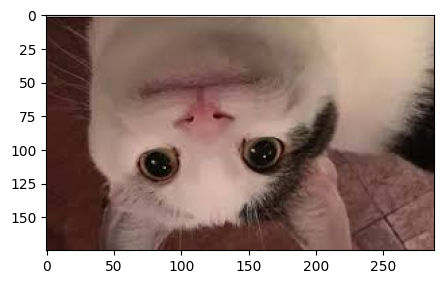

In [77]:
# flip hình ảnh cat theo chiều dọc sử dụng thư viện PIL
im_flip = ImageOps.flip(image)
plt.figure(figsize=(5,5))
plt.imshow(im_flip)
plt.show()

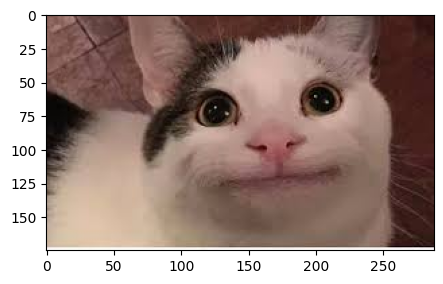

In [78]:
# flip hình ảnh cat theo chiều ngang sử dụng thư viện PIL
im_mirror = ImageOps.mirror(image)
plt.figure(figsize=(5,5))
plt.imshow(im_mirror)
plt.show()

We can use  the <code>transpose()</code> method; the parameter is an integer indicating what type of transposition we would like to perform. For example, we can flip the image using a value of `1`.


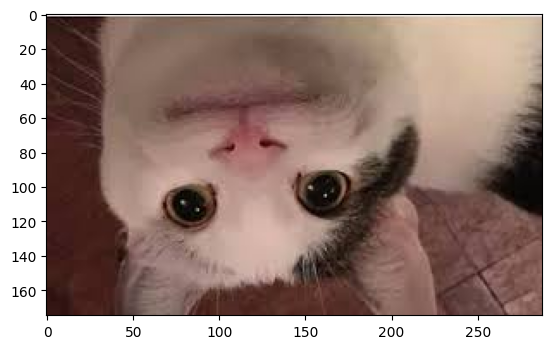

In [79]:
# flip hình ảnh bằng transpose
im_flip = image.transpose(1)
plt.imshow(im_flip)
plt.show()

The Image module has built-in attributes that describe the type of flip. The values are just integers. Several are shown in the following <code>dict</code>:


In [80]:
# tạo dict ánh xạ tên flip với giá trị tương ứng trong PIL
flip = {"FLIP_LEFT_RIGHT": Image.FLIP_LEFT_RIGHT,
        "FLIP_TOP_BOTTOM": Image.FLIP_TOP_BOTTOM,
        "ROTATE_90": Image.ROTATE_90,
        "ROTATE_180": Image.ROTATE_180,
        "ROTATE_270": Image.ROTATE_270,
        "TRANSPOSE": Image.TRANSPOSE, 
        "TRANSVERSE": Image.TRANSVERSE}

We see the values are integers.


In [81]:
# in ra giá trị số 
flip["FLIP_LEFT_RIGHT"]

0

We can plot each of the outputs using the different  parameter values:


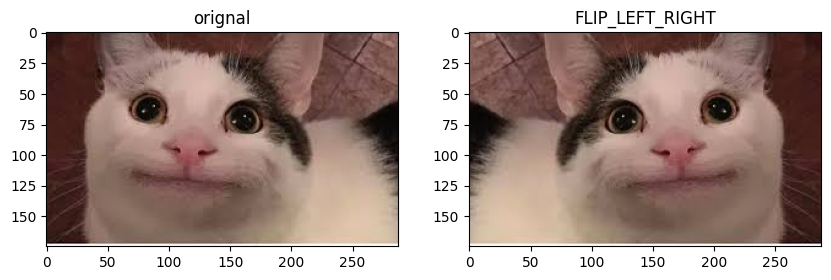

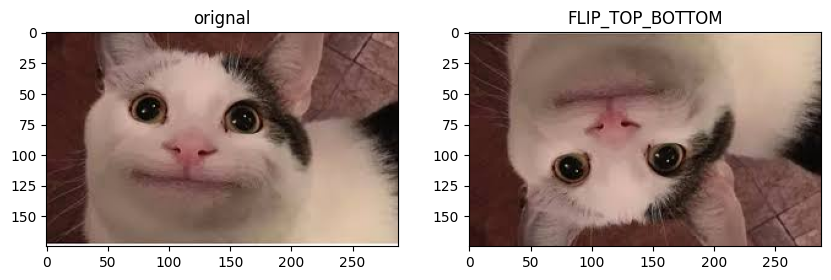

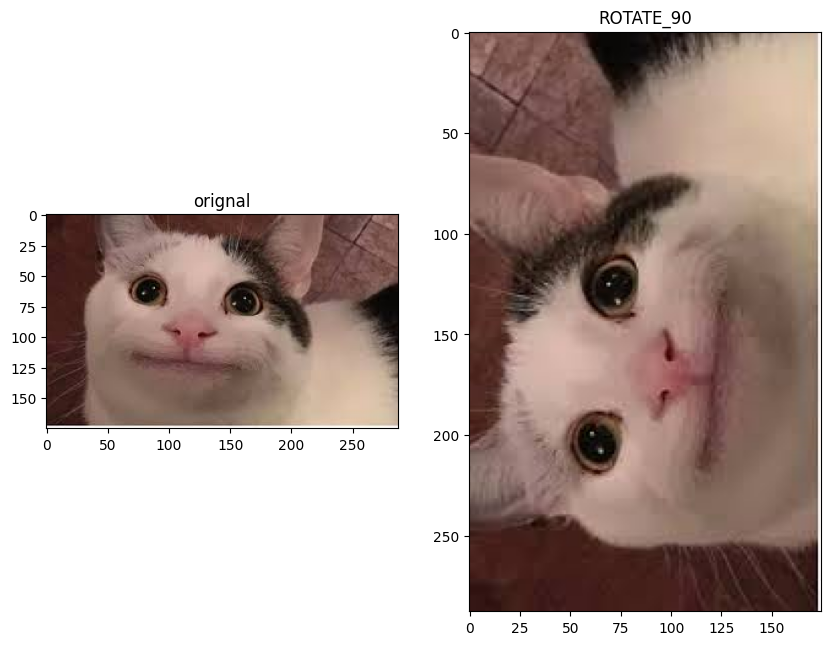

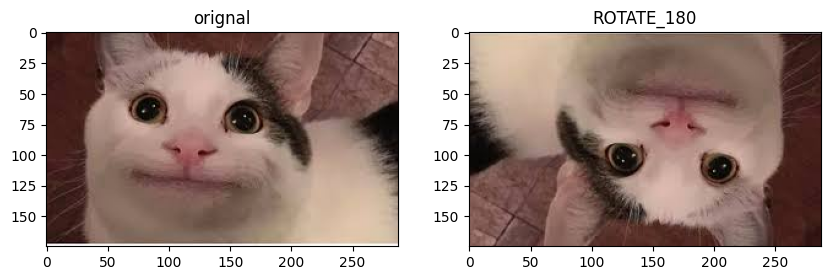

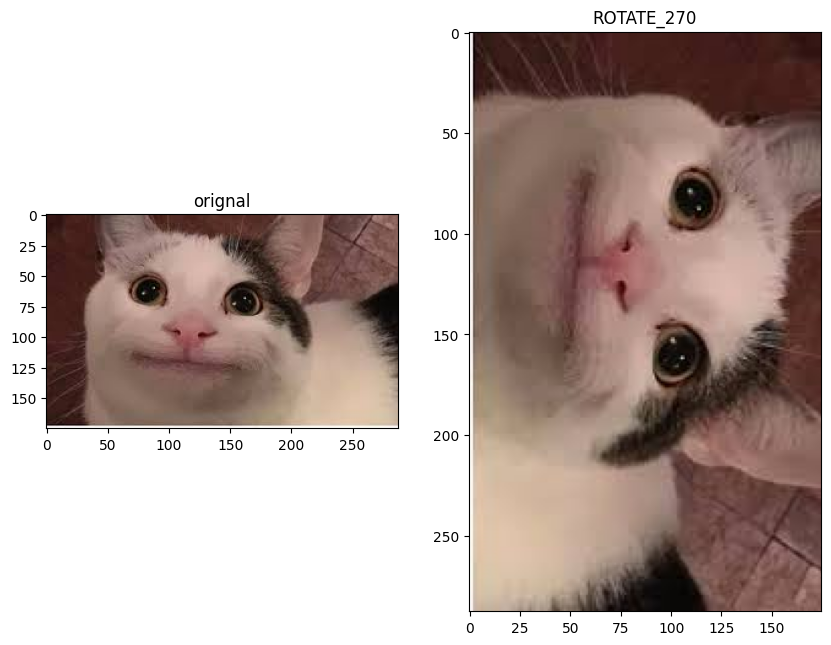

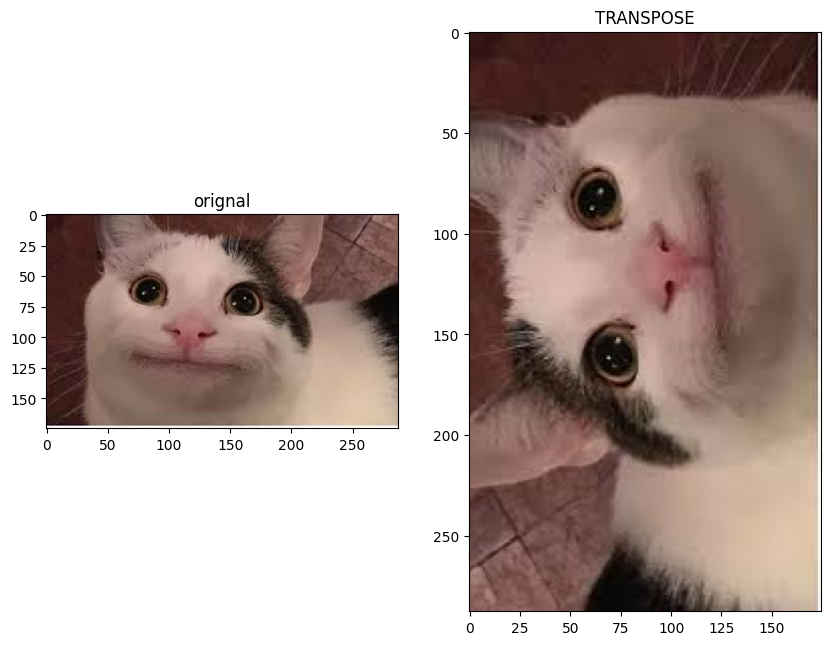

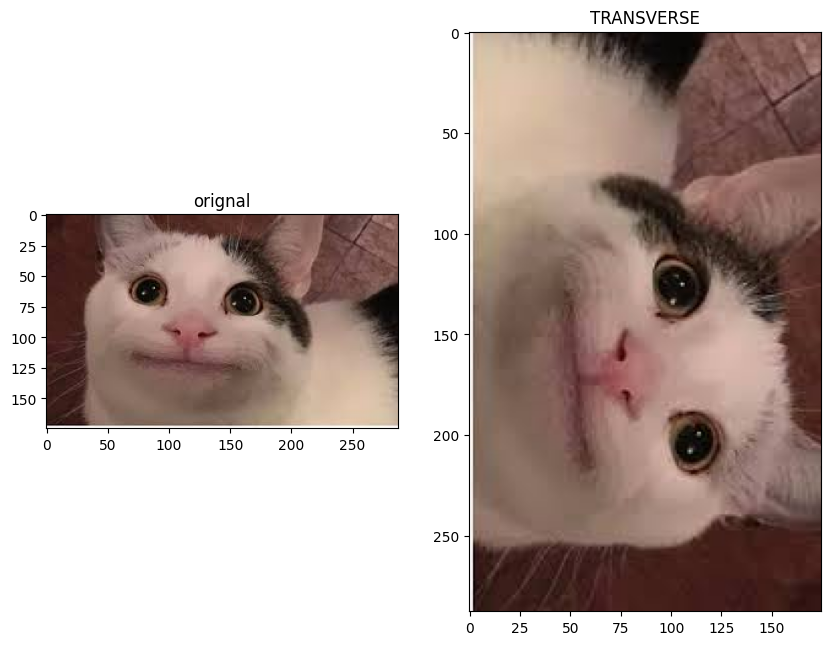

In [82]:
# Duyệt dict và hiển thị kết quả flip tương ứng
for key, values in flip.items():
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("orignal")
    plt.subplot(1,2,2)
    plt.imshow(image.transpose(values))
    plt.title(key)
    plt.show()

 ## Cropping an Image


Cropping is the act of "cutting out" a part of an image and throwing out the rest. We can perform cropping using array slicing. 

Let start with a vertical crop: the variable `upper` is the index of the first row that we would like to include in the image, the variable `lower` is the index of the last row we would like to include. We then perform array slicing to obtain the new image. 


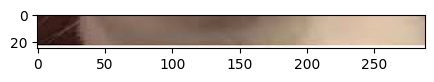

In [ ]:
# crop array từ hàng 150 đến 400 (dọc)
upper = 150
lower = 400
crop_top = array[upper: lower,:,:]
plt.figure(figsize=(5,5))
plt.imshow(crop_top)
plt.show()

Consider the array `crop_top`: we can also crop horizontally. The variable `right` is the index of the first column that we would like to include in the image and the variable `left` is the index of the last column we would like to include in the image.


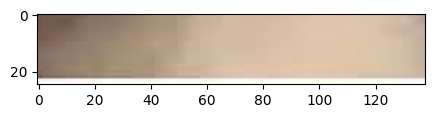

In [ ]:
# crop thêm từ cột 150 đến 400 trên crop_top (ngang)
left = 150
right = 400
crop_horizontal = crop_top[: ,left:right,:]
plt.figure(figsize=(5,5))
plt.imshow(crop_horizontal)
plt.show()

You can crop the PIL image using the <code>crop()</code> method, using the parameters from above Set the cropping area with <code>box=(left, upper, right, lower)</code>.


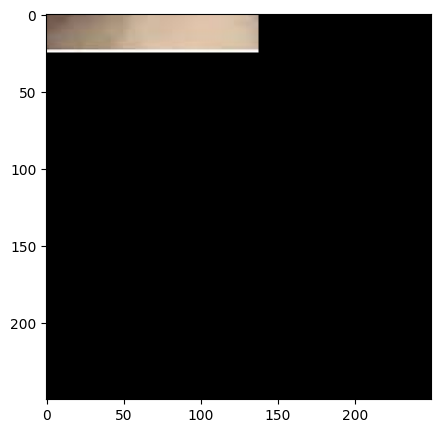

In [ ]:
# crop ảnh với các tọa độ left, upper, right, lower
image = Image.open("cat.png")
crop_image = image.crop((left, upper, right, lower))
plt.figure(figsize=(5,5))
plt.imshow(crop_image)
plt.show()

We can also flip the new image:


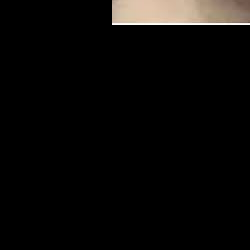

In [ ]:
# flip hình ảnh cat theo chiều ngang 
crop_image = crop_image.transpose(Image.FLIP_LEFT_RIGHT)
crop_image

## Changing Specific Image Pixels


We can change specific image pixels using  array indexing; for example, we can set  all the green and blue channels in the original image we cropped to zero:


In [ ]:
# sao chép array và đặt kênh G và B của vùng crop thành 0
array_sq = np.copy(array)
array_sq[upper:lower, left:right, 1:3] = 0

We can compare the results with the new image. 


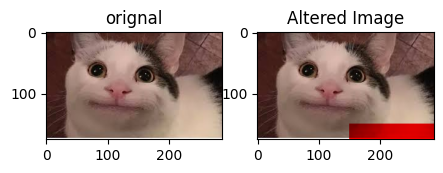

In [ ]:
# hiển thị ảnh gốc và ảnh đã thay đổi
plt.figure(figsize=(5,5))
plt.subplot(1,2,1)
plt.imshow(array)
plt.title("orignal")
plt.subplot(1,2,2)
plt.imshow(array_sq)
plt.title("Altered Image")
plt.show()

We can also use the `ImageDraw` module from `PIL` library, which provides simple 2D graphics for Image objects 


In [44]:
from PIL import ImageDraw 

We will copy the image object:


In [ ]:
# sao chép ảnh để tránh thay đổi
image_draw = image.copy()

The draw constructor creates an object that can be used to draw in the given image. The input <code>im</code> is the image we would like to draw in.



In [ ]:
# tạo đối tượng draw để vẽ trên ảnh sao chép
image_fn = ImageDraw.Draw(im=image_draw)

Whatever method we apply to the object <code>image_fn</code>, will change the image object <code>image_draw</code>.


We can draw a rectangle using the <code>rectangle</code> function, two important parameters include: <code>xy</code> – the coordinates bounding box  and <code>fill</code> – Color of the rectangle.


In [ ]:
# vẽ hình chữ nhật đỏ trên ảnh với tọa độ đã cho
shape = [left, upper, right, lower] 
image_fn.rectangle(xy=shape,fill="red")
print(image.mode)

RGB


We can plot the image.


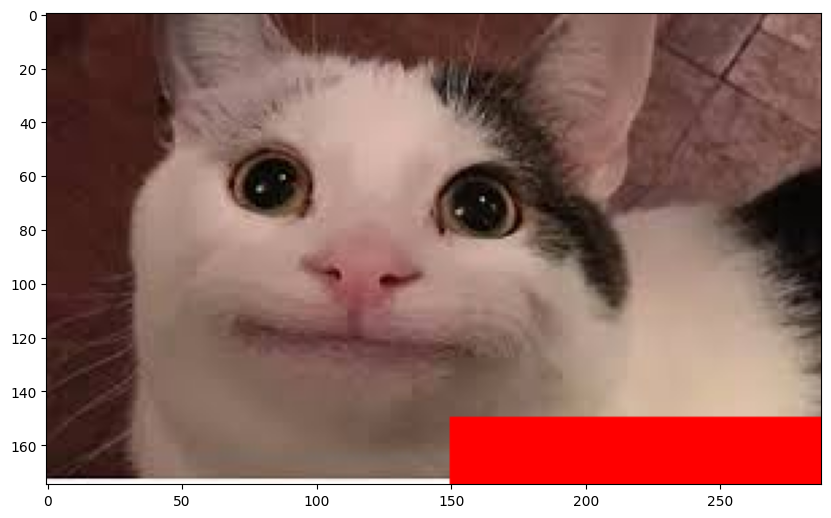

In [ ]:
# hiển thị ảnh đã vẽ hình chữ nhật đỏ
plt.figure(figsize=(10,10))
plt.imshow(image_draw)
plt.show()

There are other shapes we can use. For example, we can also overlay text on an image: we use the ImageFont module to obtain  bitmap fonts.


In [49]:
from PIL import ImageFont

We use the text method to place the text on the image. The parameters include `xy` (the top-left anchor coordinates of the text), the parameter `text` (the text to be drawn), and `fill` (the color to use for the text).


In [ ]:
# thêm text "box" vào ảnh tại tọa độ (0,0)
image_fn.text(xy=(0,0),text="box",fill=(0,0,0))

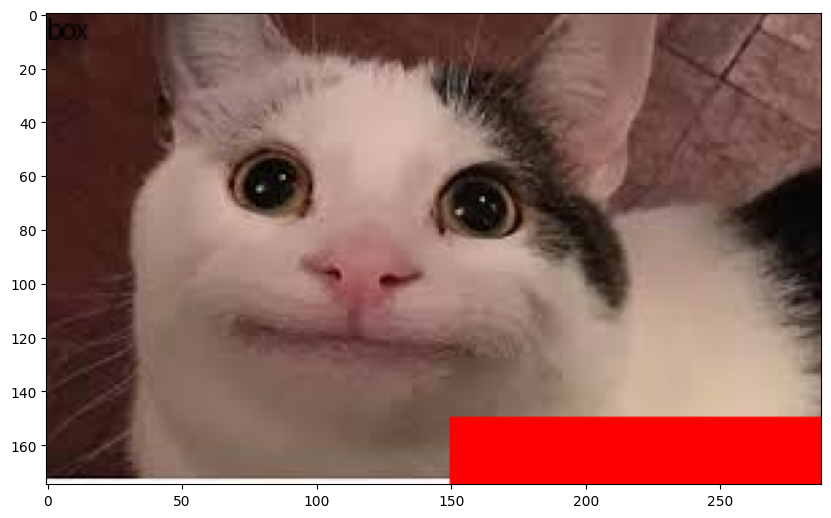

In [ ]:
# hiển thị ảnh đã vẽ hình chữ nhật đỏ và text
plt.figure(figsize=(10,10))
plt.imshow(image_draw)
plt.show()

We can overlay or paste one image over another by reassigning the pixel for one array to the next. Consider the following image array:


In [ ]:
# mở ảnh lenna.png và chuyển thành mảng numpy
image_lenna = Image.open("lenna.png")
array_lenna = np.array(image_lenna)


We can reassign the pixel values as follows:


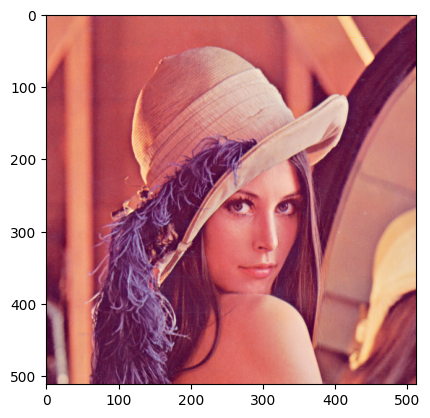

In [ ]:
# thay thế vùng crop trong ảnh lenna bằng chính nó (không thay đổi gì)
array_lenna[upper:lower,left:right,:]=array_lenna[upper:lower,left:right,:]
plt.imshow(array_lenna)
plt.show()

In the same manner, the <code>paste()</code> method allows you to overlay one image over another, with the input being the image you would like to overlay. The parameter box is the left and upper coordinate of the image:


In [ ]:
# dán vùng crop_image vào ảnh lenna tại vị trí (left, upper)
image_lenna.paste(crop_image, box=(left,upper))

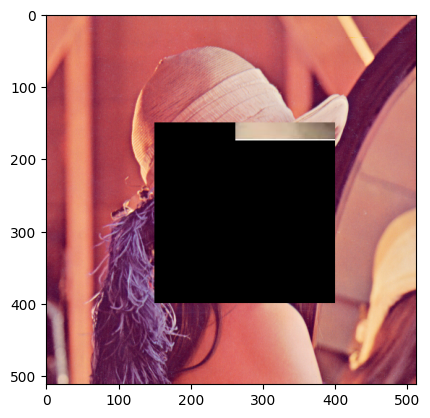

In [ ]:
# hiển thị ảnh lenna sau khi dán
plt.imshow(image_lenna)
plt.show()

We can see the method `copy()` applies to some <code>PIL</code> objects. We create two image objects, we set `new_image` to the `image`, and we use the method `copy()` for the `copy_image` object.


In [ ]:
# mở ảnh cat.png và tạo bản sao và bản copy
image = Image.open("cat.png")
new_image=image
copy_image=image.copy()

Like the array, we see that the same memory address relationship exists. For example, if we don't use the method `copy()`, the image object has the same memory address as the original PIL image object. 


In [ ]:
# kiểm tra id của image và new_image
id(image)==id(new_image)

True

If we use the method <code>copy()</code>, the address is different:


In [ ]:
# kiểm tra id của image và copy_image
id(image)==id(copy_image)

False

If we change the object <code>image</code>, <code>new_image</code> will change, but <code>copy_image</code> will remain the same:


In [ ]:
# vẽ hình chữ nhật đỏ và text "box" lên ảnh cat.png
image_fn= ImageDraw.Draw(im=image)
image_fn.text(xy=(0,0),text="box",fill=(0,0,0))
image_fn.rectangle(xy=shape,fill="red")

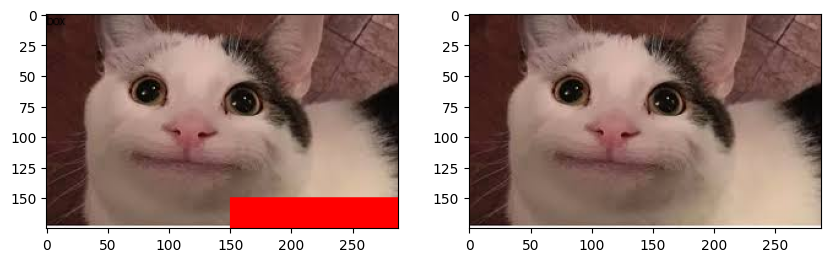

In [ ]:
# hiển thị ảnh new_image và copy_image để kiểm tra sự khác biệt
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(new_image)
plt.subplot(122)
plt.imshow(copy_image)
plt.show()

### Question 1:
Use the image `baboon.png` from this lab or take any image you like.

Open the image and create a PIL Image object called `im`, flip `im` and create an image called `im_flip`. Mirror `im` and create an image called `im_mirror`. Finally, plot both images.


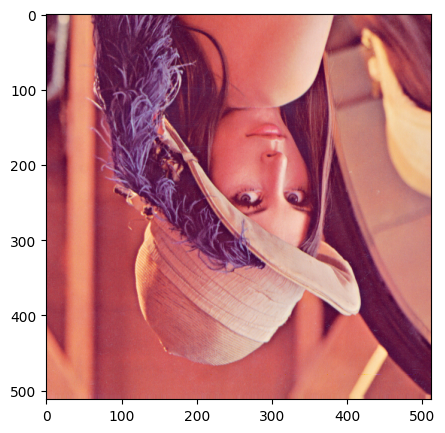

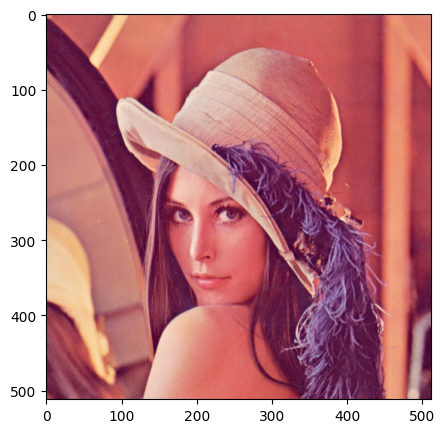

In [ ]:
# write your script here
# mở ảnh lenna.png 
im = Image.open("lenna.png")
# flip hình ảnh lenna theo chiều dọc
im_flip = ImageOps.flip(im)
plt.figure(figsize=(5,5))
plt.imshow(im_flip)
plt.show()
# flip hình ảnh lenna theo chiều ngang
im_mirror = ImageOps.mirror(im)
plt.figure(figsize=(5,5))
plt.imshow(im_mirror)
plt.show()

Double-click **here** for a hint.

<!-- The hint is below:

im_flip = ImageOps.flip(im)
im_mirror = ImageOps.mirror(im)

-->


Double-click **here** for the solution.

<!-- The answer is below:

im = Image.open("lenna.png")

im_flip = ImageOps.flip(im)
plt.figure(figsize=(5,5))
plt.imshow(im_flip)
plt.show()

im_mirror = ImageOps.mirror(im)
plt.figure(figsize=(5,5))
plt.imshow(im_mirror)
plt.show()

-->


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).


<!--<h2>Change Log</h2>-->
